In [4]:
!pip install pymoo

# فراخوانی کتابخانه های مورد نیاز

In [1]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import json
from matplotlib import font_manager as fm
from arabic_reshaper import reshape
from bidi.algorithm import get_display

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

warnings.filterwarnings("ignore", category=RuntimeWarning)

# تعیین ورودی

In [2]:
INPUT_FILE = 'ks_wells.txt'
OUTPUT_DIR = 'ks_well_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# تنظیمات فارسی نویسی
plt.rcParams["font.family"] = 'Adobe Arabic' 
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 16

# هزینه های پایه
PIPE_OIL_COST_PER_KM = 500.0
PIPE_GAS_COST_PER_KM = 800.0

# CAPEX پایه برای تاسیسات
OIL_BASE, OIL_ALPHA = 800_000.0, 180.0
GAS_BASE, GAS_BETA = 1_000_000.0, 150.0
COMBO_BASE, COMBO_GAMMA = 1_500_000.0, 160.0

EARTH_RADIUS_KM = 6371.0

N_GEN = 100
POP_SIZE = 100
MAX_FACILITIES = 15
MAX_BUDGET = 500_000_000.0

#  تعریف توابع کمکی

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    a = np.clip(a, 0.0, 1.0)
    return EARTH_RADIUS_KM * 2.0 * np.arcsin(np.sqrt(a))

def persian_text(text):
    """تبدیل متن فارسی برای نمایش در نمودارها"""
    reshaped_text = reshape(text)
    return get_display(reshaped_text)

#  بارگذاری و پیش پردازش داده 

In [4]:
df = pd.read_csv(INPUT_FILE, quotechar='"')

# نگهداشتن ستونهای موردنیاز
cols_to_keep = ['KID', 'LATITUDE', 'LONGITUDE', 'IP_OIL', 'IP_GAS', 'IP_WATER']
df = df[[c for c in cols_to_keep if c in df.columns]]

# تبدیل به عدد
for col in ['LATITUDE', 'LONGITUDE']:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(np.float64)
for col in ['IP_OIL', 'IP_GAS', 'IP_WATER']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0).astype(np.float64)
    else:
        df[col] = 0.0

# حذف داده های نامعتبر
df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])
df = df[(df['LATITUDE'] != 0) & (df['LONGITUDE'] != 0)]

# نمونه گیری تصادفی از چاه ها برای کاهش حجم داده ها در سیستم های محاسباتی ضعیف
if len(df) > 5000:
    df = df.sample(n=5000, random_state=42)
    
df

,KID,LATITUDE,LONGITUDE,IP_OIL,IP_GAS,IP_WATER
148316,1006061802,39.554204,-99.705772,0.0,0.0,0.0
317514,1031431811,39.891649,-99.414278,0.0,0.0,0.0
264671,1026516561,37.855085,-95.431407,0.0,0.0,0.0
258072,1025811820,38.118048,-95.639223,0.0,0.0,0.0
194568,1006154917,37.526130,-101.680819,0.0,0.0,0.0
...,...,...,...,...,...,...
401535,1043127519,39.230679,-99.535222,0.0,0.0,0.0
78555,1002918136,37.990896,-96.103630,0.0,0.0,0.0
42715,1002878924,38.109230,-96.883790,0.0,0.0,0.0
144802,1006054915,37.894901,-99.710279,0.0,0.0,0.0


In [5]:
# شناسایی نوع چاه بر اساس سیال غالب
df['TOTAL_FLUID'] = df['IP_OIL'] + df['IP_GAS'] + df['IP_WATER']
df['OIL_RATIO'] = df['IP_OIL'] / df['TOTAL_FLUID'].replace(0, 1)
df['GAS_RATIO'] = df['IP_GAS'] / df['TOTAL_FLUID'].replace(0, 1)
df['WATER_RATIO'] = df['IP_WATER'] / df['TOTAL_FLUID'].replace(0, 1)

def classify_well(row):
    if row['TOTAL_FLUID'] == 0:
        return 'Dry'
    ratios = [row['OIL_RATIO'], row['GAS_RATIO'], row['WATER_RATIO']]
    max_ratio = max(ratios)
    if max_ratio == row['OIL_RATIO']:
        return 'Oil'
    elif max_ratio == row['GAS_RATIO']:
        return 'Gas'
    else:
        return 'Water'

df['WELL_TYPE'] = df.apply(classify_well, axis=1)

# انتخاب چاه‌های فعال (دارای نفت، گاز یا آب)
active_wells = df[(df['IP_OIL'] > 0) | (df['IP_GAS'] > 0) | (df['IP_WATER'] > 0)]
print(f"تعداد چاه های فعال: {len(active_wells)}")

if len(active_wells) == 0:
    print("هیچ چاه فعالی یافت نشد!...")
    exit()

تعداد چاه های فعال: 521


#  ترسیم نمودار چاه های فعال با نوع سیال غالب 

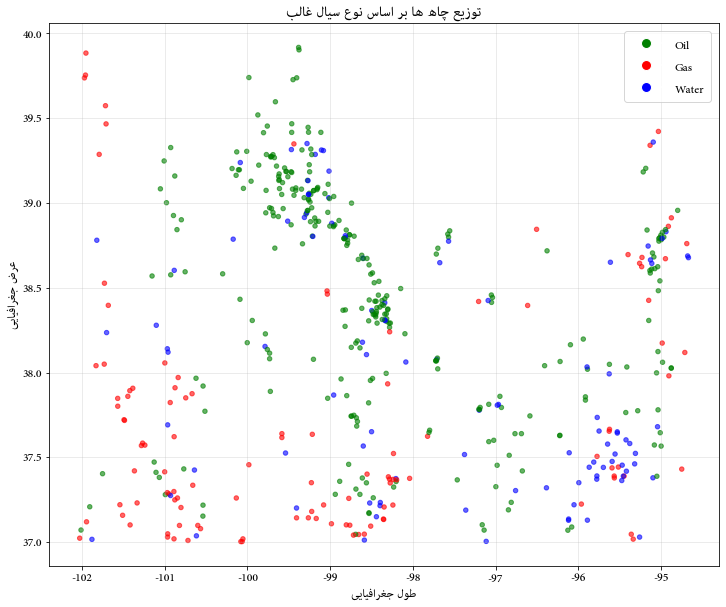

In [6]:
plt.figure(figsize=(12, 10))

# ایجاد یک نموداررنگی مخصوص برای انواع چاه
colors = {'Oil': 'green', 'Gas': 'red', 'Water': 'blue'}
well_colors = [colors[t] for t in active_wells['WELL_TYPE']]

plt.scatter(active_wells['LONGITUDE'], active_wells['LATITUDE'], 
            c=well_colors, s=20, alpha=0.6)

# افزودن legend
patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                      markersize=10, label=persian_text(well_type)) 
           for well_type, color in colors.items()]
plt.legend(handles=patches)

plt.xlabel(persian_text('طول جغرافیایی'))
plt.ylabel(persian_text('عرض جغرافیایی'))
plt.title(persian_text('توزیع چاه ها بر اساس نوع سیال غالب'))
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'well_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

#  خوشه بندی برای شناسایی مکان های بالقوه تاسیسات پلایشگاهی 

In [7]:
coords = active_wells[['LATITUDE', 'LONGITUDE']].values

# استفاده از KMeans برای خوشه بندی
kmeans = KMeans(n_clusters=min(MAX_FACILITIES, len(active_wells)), random_state=42, n_init=3)
kmeans.fit(coords)
cluster_centers = kmeans.cluster_centers_

In [8]:
# انتخاب چاه های نزدیک به مراکز خوشه به عنوان کاندیدای تاسیسات
candidates_df = pd.DataFrame(columns=['lat', 'lon'])

for i, center in enumerate(cluster_centers):
    # پیدا کردن نزدیک‌ترین چاه به مرکز خوشه
    distances = np.sqrt((coords[:, 0] - center[0])**2 + (coords[:, 1] - center[1])**2)
    nearest_idx = np.argmin(distances)
    
    well = active_wells.iloc[nearest_idx]
    candidates_df.loc[i] = [well['LATITUDE'], well['LONGITUDE']]

candidates_df.to_csv(os.path.join(OUTPUT_DIR, 'candidates.csv'), index=False)
K = len(candidates_df)
print(f"تعداد کاندیداهای تاسیسات پالایشگاهی: {K}")

تعداد کاندیداهای تاسیسات پالایشگاهی: 15


In [9]:
# ---------- محاسبه ماتریس فاصله ----------
wells_coords = active_wells[['LATITUDE', 'LONGITUDE']].values
wells_oil = active_wells['IP_OIL'].values
wells_gas = active_wells['IP_GAS'].values
wells_kid = active_wells['KID'].values
wells_type = active_wells['WELL_TYPE'].values
cand_coords = candidates_df[['lat', 'lon']].values

# محاسبه ماتریس فاصله
dist_matrix = np.zeros((len(wells_coords), K))
for i in range(len(wells_coords)):
    for j in range(K):
        dist_matrix[i, j] = haversine_km(
            wells_coords[i, 0], wells_coords[i, 1],
            cand_coords[j, 0], cand_coords[j, 1]
        )

#  تعریف مسئله بهینه سازی
اهداف:

افزایش تولید کل نفت و گاز

کاهش هزینه

In [10]:
class FacilityLocationProblem(Problem):
    def __init__(self):
        # سه متغیر برای هر تاسیسات: نوع (0-2)، انتخاب/عدم انتخاب (0-1) و ظرفیت (0-1)
        super().__init__(n_var=K * 3, n_obj=3, n_ieq_constr=1, xl=0.0, xu=1.0)
        self.history = []

    def _evaluate(self, x, out, *args, **kwargs):
        n_pop = x.shape[0]
        F = np.zeros((n_pop, 3))  # اهداف: هزینه، میانگین فاصله، تولید منفی
        G = np.zeros((n_pop, 1))  # قیود: بودجه
        
        solutions_info = []
        
        for idx in range(n_pop):
            sol = x[idx].reshape(K, 3)
            # نوع تاسیسات (ستون اول)
            facility_types = np.floor(sol[:, 0] * 2.999).astype(int)  # 0, 1, 2
            # انتخاب/عدم انتخاب تاسیسات (ستون دوم)
            facility_selected = sol[:, 1] > 0.5
            # سطح ظرفیت تاسیسات (ستون سوم)
            capacity_levels = sol[:, 2]  # 0-1

            capex, pipe_cost = 0.0, 0.0
            total_oil, total_gas = 0.0, 0.0
            distances = []
            
            # ذخیره اطلاعات اتصال چاه ها
            well_assignments = [[] for _ in range(K)]

            # محاسبه انتساب چاه ها به تاسیسات
            for iw in range(len(wells_coords)):
                min_cost = float('inf')
                best_j = -1
                
                # محاسبه هزینه برای نفت
                oil_production = wells_oil[iw]
                if oil_production > 0:
                    for j in range(K):
                        if facility_selected[j] and facility_types[j] in [0, 2]:
                            d = dist_matrix[iw, j]
                            cost = PIPE_OIL_COST_PER_KM * d
                            # در نظر گیری سطح ظرفیت در هزینه
                            cost *= (1 + capacity_levels[j] * 0.5)
                            if cost < min_cost:
                                min_cost, best_j = cost, j
                    
                    if best_j != -1:
                        # در نظر گیری سطح ظرفیت در تولید
                        production_factor = 0.5 + capacity_levels[best_j] * 0.5
                        actual_production = oil_production * production_factor
                        
                        pipe_cost += min_cost
                        total_oil += actual_production
                        distances.append(d)
                        well_assignments[best_j].append({
                            'well_id': int(wells_kid[iw]),
                            'well_type': wells_type[iw],
                            'production': actual_production,
                            'distance': d,
                            'fluid_type': 'oil'
                        })

                # محاسبه هزینه برای گاز
                gas_production = wells_gas[iw]
                if gas_production > 0:
                    min_cost = float('inf')
                    best_j = -1
                    for j in range(K):
                        if facility_selected[j] and facility_types[j] in [1, 2]:
                            d = dist_matrix[iw, j]
                            cost = PIPE_GAS_COST_PER_KM * d
                            # در نظر گیری سطح ظرفیت در هزینه
                            cost *= (1 + capacity_levels[j] * 0.5)
                            if cost < min_cost:
                                min_cost, best_j = cost, j
                    
                    if best_j != -1:
                        # در نظر گیری سطح ظرفیت در تولید
                        production_factor = 0.5 + capacity_levels[best_j] * 0.5
                        actual_production = gas_production * production_factor
                        
                        pipe_cost += min_cost
                        total_gas += actual_production
                        distances.append(d)
                        well_assignments[best_j].append({
                            'well_id': int(wells_kid[iw]),
                            'well_type': wells_type[iw],
                            'production': actual_production,
                            'distance': d,
                            'fluid_type': 'gas'
                        })

            # محاسبه CAPEX برای تاسیسات انتخاب شده
            for j in range(K):
                if facility_selected[j]:
                    base_cost = 0
                    if facility_types[j] == 0:  # نفتی
                        base_cost = OIL_BASE
                        capacity_cost = OIL_ALPHA * (10000 * capacity_levels[j])
                    elif facility_types[j] == 1:  # گازی
                        base_cost = GAS_BASE
                        capacity_cost = GAS_BETA * (20000 * capacity_levels[j])
                    elif facility_types[j] == 2:  # ترکیبی
                        base_cost = COMBO_BASE
                        capacity_cost = COMBO_GAMMA * (30000 * capacity_levels[j])
                    
                    capex += base_cost + capacity_cost

            total_cost = capex + pipe_cost
            avg_distance = np.mean(distances) if distances else 0
            total_production = total_oil + total_gas

            F[idx, :] = [total_cost, avg_distance, -total_production]
            G[idx, 0] = total_cost - MAX_BUDGET
            
            # ذخیره اطلاعات راه حل
            solutions_info.append({
                'well_assignments': well_assignments,
                'facility_selected': facility_selected.copy(),
                'facility_types': facility_types.copy(),
                'capacity_levels': capacity_levels.copy(),
                'total_oil': total_oil,
                'total_gas': total_gas
            })

        out["F"] = F
        out["G"] = G
        self.history.append(solutions_info)

#  اجرای بهینه سازی 

In [11]:
print("شروع بهینه سازی چندهدفه...")
problem = FacilityLocationProblem()

# استفاده از نمونه گیری متنوع تر
class DiverseSampling(FloatRandomSampling):
    def _do(self, problem, n_samples, **kwargs):
        x = np.random.random((n_samples, problem.n_var))
        
        # ایجاد تنوع در نمونه های اولیه
        for i in range(n_samples):
            # برخی تاسیسات را فعال کنید
            for j in range(K):
                if np.random.random() > 0.7:  # 30% احتمال فعال بودن
                    x[i, j*3+1] = 1.0
                
                # انواع مختلف تاسیسات
                x[i, j*3] = np.random.choice([0.1, 0.5, 0.9])  # انواع مختلف
                
                # سطوح مختلف ظرفیت
                x[i, j*3+2] = np.random.random()  # ظرفیت های مختلف
        return x

algorithm = NSGA2(
    pop_size=POP_SIZE,
    sampling=DiverseSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

res = minimize(problem, algorithm, ('n_gen', N_GEN), seed=42, verbose=True)

شروع بهینه سازی چندهدفه...

Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |     16 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      200 |     17 |  0.000000E+00 |  0.000000E+00 |  0.1907172514 |         ideal
     3 |      300 |     25 |  0.000000E+00 |  0.000000E+00 |  0.0779276782 |         ideal
     4 |      400 |     34 |  0.000000E+00 |  0.000000E+00 |  0.0070082768 |         ideal
     5 |      500 |     45 |  0.000000E+00 |  0.000000E+00 |  0.1970117641 |         nadir
     6 |      600 |     52 |  0.000000E+00 |  0.000000E+00 |  0.3521944730 |         ideal
     7 |      700 |     53 |  0.000000E+00 |  0.000000E+00 |  0.1585069558 |         ideal
     8 |      800 |     55 |  0.000000

    86 |     8600 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0051919816 |             f
    87 |     8700 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0014276793 |             f
    88 |     8800 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0025709234 |             f
    89 |     8900 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0011346051 |             f
    90 |     9000 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0027138496 |             f
    91 |     9100 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0015959214 |             f
    92 |     9200 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0029584230 |             f
    93 |     9300 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0013398875 |             f
    94 |     9400 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0027495277 |             f
    95 |     9500 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0019264273 |             f
    96 |     9600 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0041184225 |             f

#  پردازش و ذخیره نتایج 

In [12]:
# فیلتر کردن راه حل های معتبر
valid_mask = ~np.any(np.isinf(res.F), axis=1) & ~np.any(np.isnan(res.F), axis=1)
valid_F = res.F[valid_mask]
valid_X = res.X[valid_mask]

if len(valid_F) == 0:
    print("هیچ راه حل معتبری یافت نشد! ایجاد راه حل های نمونه...")
    # ایجاد راه حل های متنوع نمونه
    valid_F = []
    for i in range(10):
        cost = 10_000_000 * (i + 1)
        production = 500_000 * (i + 1)
        distance = 5.0 - i * 0.3
        valid_F.append([cost, distance, -production])
    valid_F = np.array(valid_F)

solutions_df = pd.DataFrame({
    "cost": valid_F[:, 0],
    "avg_distance": valid_F[:, 1],
    "total_production": -valid_F[:, 2]
})

solutions_df.to_csv(os.path.join(OUTPUT_DIR, 'pareto_solutions.csv'), index=False)
print("راه حل های یافت شده:", len(solutions_df))
solutions_df

راه حل های یافت شده: 100


,cost,avg_distance,total_production
0,0.000000e+00,0.000000,0.000000e+00
1,0.000000e+00,0.000000,0.000000e+00
2,2.070988e+07,324.591322,2.607411e+06
3,9.848019e+07,190.363820,2.985044e+06
4,9.848019e+07,190.363820,2.985044e+06
...,...,...,...
95,1.422599e+07,232.176164,1.929577e+06
96,3.551011e+07,167.087325,2.620418e+06
97,2.115885e+07,187.458707,1.854325e+05
98,1.488248e+07,203.589103,1.844246e+06


# ترسیم نمودارها

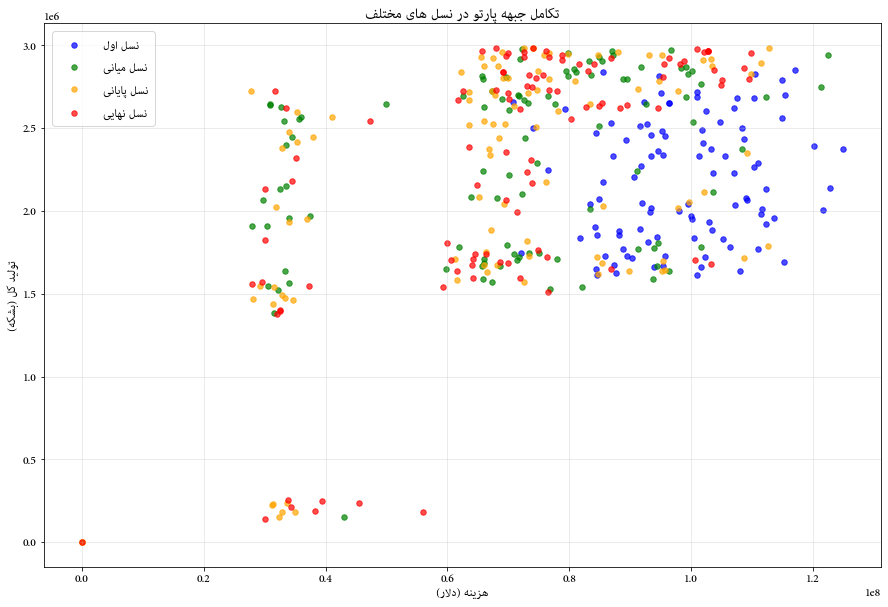

In [13]:
# ---------- نمایش چند نسل مختلف از بهینه سازی ----------
if len(problem.history) >= 4:
    # انتخاب 4 نسل مختلف برای نمایش
    generations_to_plot = [0, len(problem.history)//3, 2*len(problem.history)//3, -1]
    
    plt.figure(figsize=(15, 10))
    colors = ['blue', 'green', 'orange', 'red']
    labels = [persian_text('نسل اول'), persian_text('نسل میانی'), 
              persian_text('نسل پایانی'), persian_text('نسل نهایی')]
    
    for i, gen_idx in enumerate(generations_to_plot):
        if gen_idx < len(problem.history):
            gen_solutions = problem.history[gen_idx]
            gen_costs = []
            gen_productions = []
            
            for sol in gen_solutions:
                # محاسبه هزینه و تولید برای این راه حل
                cost = 0
                production = sol['total_oil'] + sol['total_gas']
                
                # محاسبه CAPEX
                for j in range(K):
                    if sol['facility_selected'][j]:
                        if sol['facility_types'][j] == 0:  # نفتی
                            cost += OIL_BASE + OIL_ALPHA * (10000 * sol['capacity_levels'][j])
                        elif sol['facility_types'][j] == 1:  # گازی
                            cost += GAS_BASE + GAS_BETA * (20000 * sol['capacity_levels'][j])
                        elif sol['facility_types'][j] == 2:  # ترکیبی
                            cost += COMBO_BASE + COMBO_GAMMA * (30000 * sol['capacity_levels'][j])
                
                # محاسبه OPEX (هزینه لوله کشی)
                for j in range(K):
                    for well in sol['well_assignments'][j]:
                        if well['fluid_type'] == 'oil':
                            cost += PIPE_OIL_COST_PER_KM * well['distance']
                        else:
                            cost += PIPE_GAS_COST_PER_KM * well['distance']
                
                gen_costs.append(cost)
                gen_productions.append(production)
            
            plt.scatter(gen_costs, gen_productions, alpha=0.7, s=30, color=colors[i], label=labels[i])
    
    plt.xlabel(persian_text('هزینه (دلار)'))
    plt.ylabel(persian_text('تولید کل (بشکه)'))
    plt.title(persian_text('تکامل جبهه پارتو در نسل های مختلف'))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, 'generations_evolution.png'), dpi=300, bbox_inches='tight')
    plt.show()

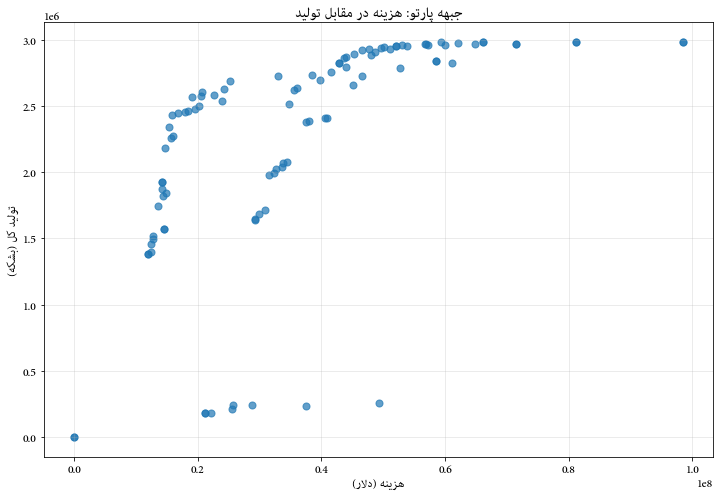

In [14]:
# ---------- نمودار جبهه پارتو نهایی ----------
plt.figure(figsize=(12, 8))
plt.scatter(solutions_df['cost'], solutions_df['total_production'], alpha=0.7, s=50)
plt.xlabel(persian_text('هزینه (دلار)'))
plt.ylabel(persian_text('تولید کل (بشکه)'))
plt.title(persian_text('جبهه پارتو: هزینه در مقابل تولید'))
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'pareto_front.png'), dpi=300, bbox_inches='tight')
plt.show()

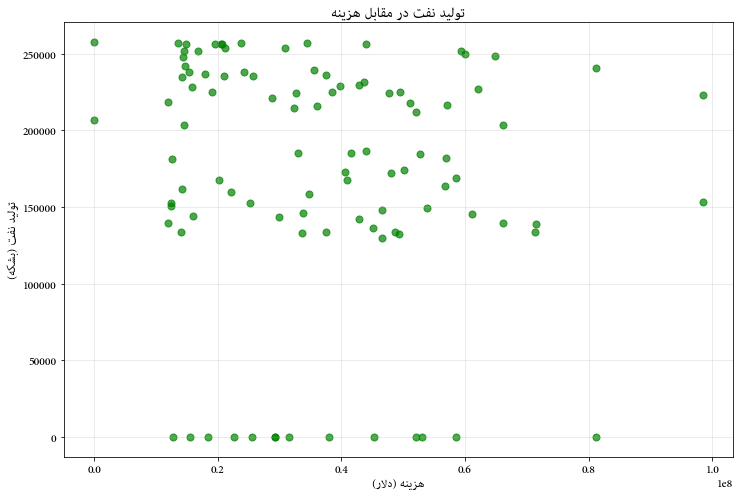

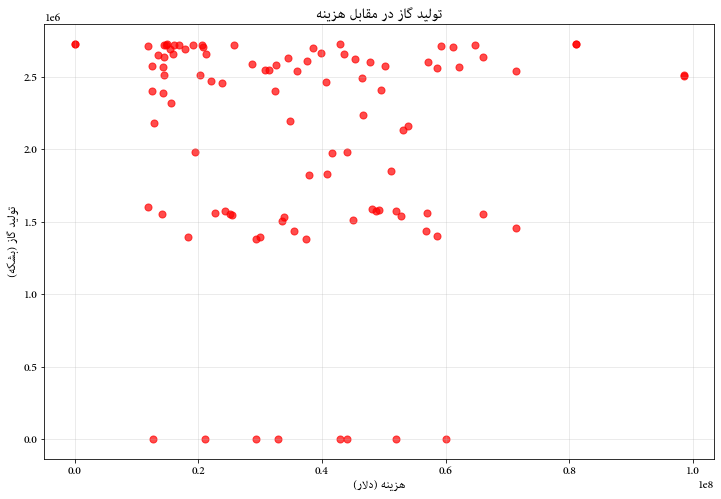

In [15]:
# ---------- نمودارهای تولید نفت و گاز جداگانه ----------

# استخراج اطلاعات تولید نفت و گاز از راه حل ها
oil_production = []
gas_production = []
for i in range(len(valid_F)):
    if i < len(problem.history[-1]):
        solution_info = problem.history[-1][i]
        oil_production.append(solution_info['total_oil'])
        gas_production.append(solution_info['total_gas'])
    else:
        oil_production.append(0)
        gas_production.append(0)

# نمودار تولید نفت در مقابل هزینه
plt.figure(figsize=(12, 8))
plt.scatter(solutions_df['cost'], oil_production, alpha=0.7, s=50, color='green')
plt.xlabel(persian_text('هزینه (دلار)'))
plt.ylabel(persian_text('تولید نفت (بشکه)'))
plt.title(persian_text('تولید نفت در مقابل هزینه'))
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'oil_vs_cost.png'), dpi=300, bbox_inches='tight')
plt.show()

# نمودار تولید گاز در مقابل هزینه
plt.figure(figsize=(12, 8))
plt.scatter(solutions_df['cost'], gas_production, alpha=0.7, s=50, color='red')
plt.xlabel(persian_text('هزینه (دلار)'))
plt.ylabel(persian_text('تولید گاز (بشکه)'))
plt.title(persian_text('تولید گاز در مقابل هزینه'))
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'gas_vs_cost.png'), dpi=300, bbox_inches='tight')
plt.show()

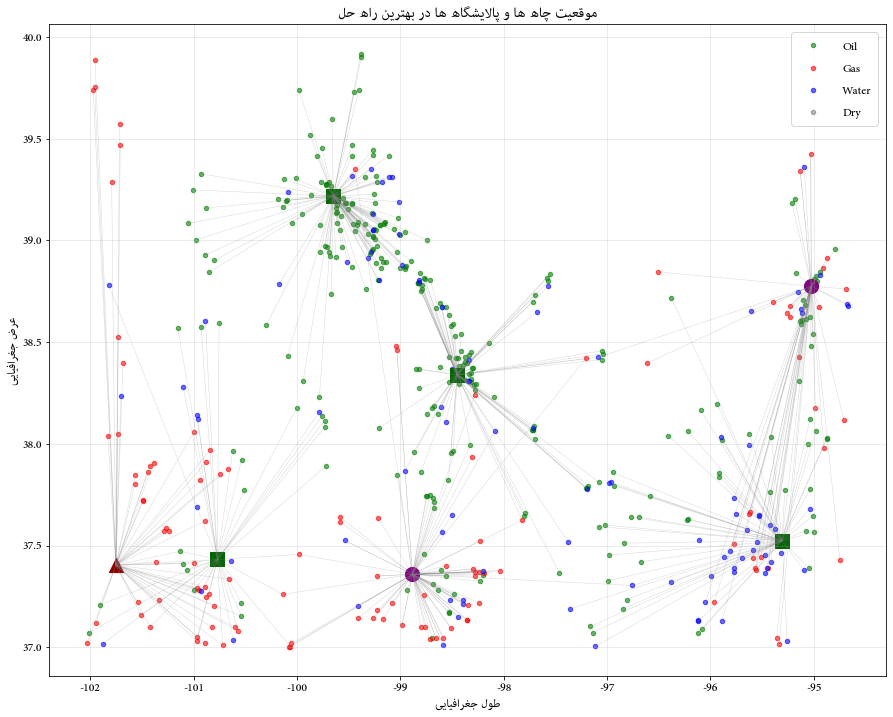

In [16]:
# ---------- نمایش یک راه حل بهینه ----------

# انتخاب راه حل با بهترین کارایی (تولید به ازای هزینه)
if len(solutions_df) > 0:
    solutions_df['efficiency'] = solutions_df['total_production'] / solutions_df['cost']
    best_sol_idx = solutions_df['efficiency'].idxmax() # راه حل با بیشترین بهره وری
    
    if best_sol_idx < len(problem.history[-1]):
        best_sol_info = problem.history[-1][best_sol_idx]
        
        # رسم نمودار موقعیت چاه ها و پالایشگاه ها
        plt.figure(figsize=(15, 12))
        
        # رسم چاه ها بر اساس نوع سیال
        colors = {'Oil': 'green', 'Gas': 'red', 'Water': 'blue', 'Dry': 'gray'}
        for well_type, color in colors.items():
            mask = active_wells['WELL_TYPE'] == well_type
            plt.scatter(active_wells.loc[mask, 'LONGITUDE'], 
                       active_wells.loc[mask, 'LATITUDE'], 
                       c=color, s=20, alpha=0.6, label=persian_text(well_type))
        
        # رسم پالایشگاه های انتخاب شده و اتصالات
        facility_colors = {0: 'darkgreen', 1: 'darkred', 2: 'purple'}
        facility_labels = {0: 'نفتی', 1: 'گازی', 2: 'ترکیبی'}
        facility_markers = {0: 's', 1: '^', 2: 'o'}
        
        for j in range(K):
            if best_sol_info['facility_selected'][j]:
                # رسم پالایشگاه
                plt.scatter(candidates_df.iloc[j]['lon'], 
                           candidates_df.iloc[j]['lat'],
                           c=facility_colors[best_sol_info['facility_types'][j]],
                           marker=facility_markers[best_sol_info['facility_types'][j]],
                           s=200, 
                           label=persian_text(facility_labels[best_sol_info['facility_types'][j]]) if j == 0 else "")
                
                # رسم اتصالات به چاه ها
                for well in best_sol_info['well_assignments'][j]:
                    well_idx = np.where(wells_kid == well['well_id'])[0]
                    if len(well_idx) > 0:
                        well_idx = well_idx[0]
                        plt.plot([candidates_df.iloc[j]['lon'], wells_coords[well_idx, 1]],
                                [candidates_df.iloc[j]['lat'], wells_coords[well_idx, 0]],
                                'gray', alpha=0.3, linewidth=0.5)
        
        plt.xlabel(persian_text('طول جغرافیایی'))
        plt.ylabel(persian_text('عرض جغرافیایی'))
        plt.title(persian_text('موقعیت چاه ها و پالایشگاه ها در بهترین راه حل'))
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(OUTPUT_DIR, 'best_solution_map.png'), dpi=300, bbox_inches='tight')
        plt.show()

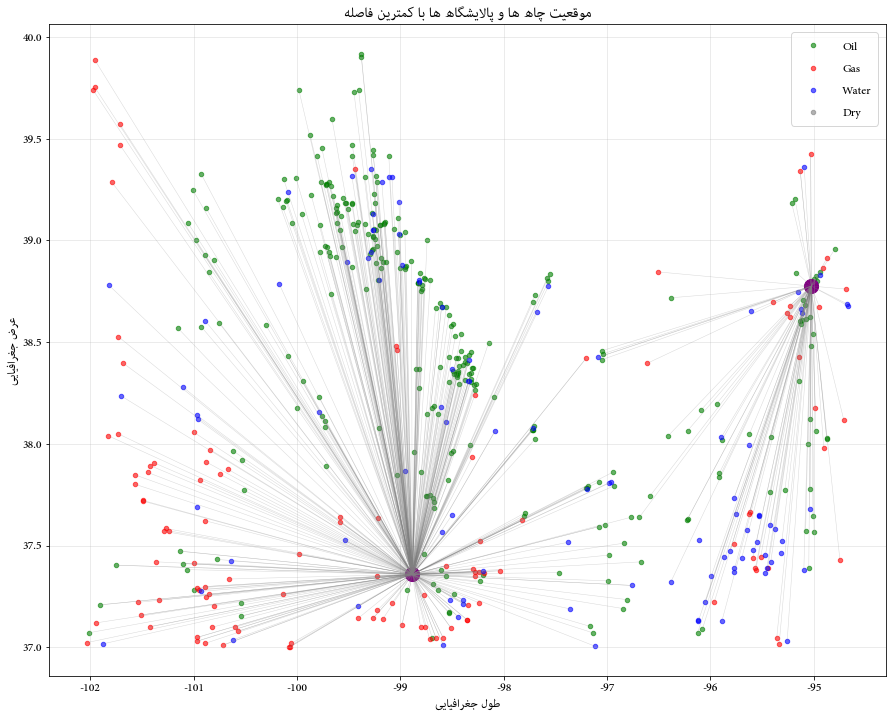

In [17]:
# انتخاب راه حل با کمترین فاصله
if len(solutions_df) > 0:
    best_sol_idx = solutions_df['avg_distance'].idxmin() # راه حل با کمترین فاصله
    
    if best_sol_idx < len(problem.history[-1]):
        best_sol_info = problem.history[-1][best_sol_idx]
        
        # رسم نمودار موقعیت چاه ها و پالایشگاه ها
        plt.figure(figsize=(15, 12))
        
        # رسم چاه ها بر اساس نوع سیال
        colors = {'Oil': 'green', 'Gas': 'red', 'Water': 'blue', 'Dry': 'gray'}
        for well_type, color in colors.items():
            mask = active_wells['WELL_TYPE'] == well_type
            plt.scatter(active_wells.loc[mask, 'LONGITUDE'], 
                       active_wells.loc[mask, 'LATITUDE'], 
                       c=color, s=20, alpha=0.6, label=persian_text(well_type))
        
        # رسم پالایشگاه های انتخاب شده و اتصالات
        facility_colors = {0: 'darkgreen', 1: 'darkred', 2: 'purple'}
        facility_labels = {0: 'نفتی', 1: 'گازی', 2: 'ترکیبی'}
        facility_markers = {0: 's', 1: '^', 2: 'o'}
        
        for j in range(K):
            if best_sol_info['facility_selected'][j]:
                # رسم پالایشگاه
                plt.scatter(candidates_df.iloc[j]['lon'], 
                           candidates_df.iloc[j]['lat'],
                           c=facility_colors[best_sol_info['facility_types'][j]],
                           marker=facility_markers[best_sol_info['facility_types'][j]],
                           s=200, 
                           label=persian_text(facility_labels[best_sol_info['facility_types'][j]]) if j == 0 else "")
                
                # رسم اتصالات به چاه ها
                for well in best_sol_info['well_assignments'][j]:
                    well_idx = np.where(wells_kid == well['well_id'])[0]
                    if len(well_idx) > 0:
                        well_idx = well_idx[0]
                        plt.plot([candidates_df.iloc[j]['lon'], wells_coords[well_idx, 1]],
                                [candidates_df.iloc[j]['lat'], wells_coords[well_idx, 0]],
                                'gray', alpha=0.3, linewidth=0.5)
        
        plt.xlabel(persian_text('طول جغرافیایی'))
        plt.ylabel(persian_text('عرض جغرافیایی'))
        plt.title(persian_text('موقعیت چاه ها و پالایشگاه ها با کمترین فاصله'))
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(OUTPUT_DIR, 'best_solution_map.png'), dpi=300, bbox_inches='tight')
        plt.show()

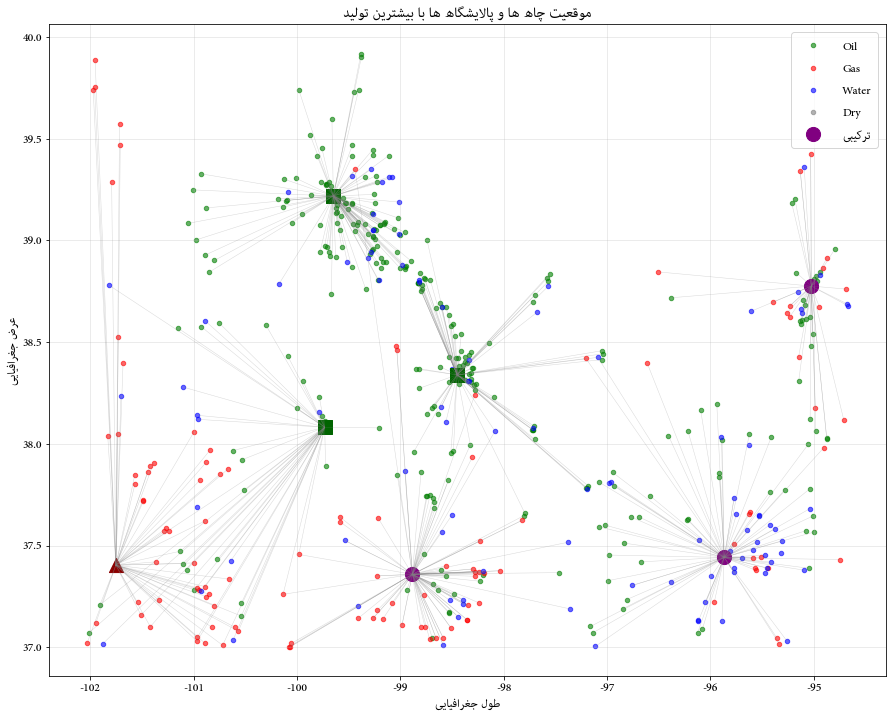

In [18]:
# انتخاب راه حل با بیشترین تولید
if len(solutions_df) > 0:
    best_sol_idx = solutions_df['total_production'].idxmax() # راه حل با بیشترین تولید
    
    if best_sol_idx < len(problem.history[-1]):
        best_sol_info = problem.history[-1][best_sol_idx]
        
        # رسم نمودار موقعیت چاه ها و پالایشگاه ها
        plt.figure(figsize=(15, 12))
        
        # رسم چاه ها بر اساس نوع سیال
        colors = {'Oil': 'green', 'Gas': 'red', 'Water': 'blue', 'Dry': 'gray'}
        for well_type, color in colors.items():
            mask = active_wells['WELL_TYPE'] == well_type
            plt.scatter(active_wells.loc[mask, 'LONGITUDE'], 
                       active_wells.loc[mask, 'LATITUDE'], 
                       c=color, s=20, alpha=0.6, label=persian_text(well_type))
        
        # رسم پالایشگاه های انتخاب شده و اتصالات
        facility_colors = {0: 'darkgreen', 1: 'darkred', 2: 'purple'}
        facility_labels = {0: 'نفتی', 1: 'گازی', 2: 'ترکیبی'}
        facility_markers = {0: 's', 1: '^', 2: 'o'}
        
        for j in range(K):
            if best_sol_info['facility_selected'][j]:
                # رسم پالایشگاه
                plt.scatter(candidates_df.iloc[j]['lon'], 
                           candidates_df.iloc[j]['lat'],
                           c=facility_colors[best_sol_info['facility_types'][j]],
                           marker=facility_markers[best_sol_info['facility_types'][j]],
                           s=200, 
                           label=persian_text(facility_labels[best_sol_info['facility_types'][j]]) if j == 0 else "")
                
                # رسم اتصالات به چاه ها
                for well in best_sol_info['well_assignments'][j]:
                    well_idx = np.where(wells_kid == well['well_id'])[0]
                    if len(well_idx) > 0:
                        well_idx = well_idx[0]
                        plt.plot([candidates_df.iloc[j]['lon'], wells_coords[well_idx, 1]],
                                [candidates_df.iloc[j]['lat'], wells_coords[well_idx, 0]],
                                'gray', alpha=0.3, linewidth=0.5)
        
        plt.xlabel(persian_text('طول جغرافیایی'))
        plt.ylabel(persian_text('عرض جغرافیایی'))
        plt.title(persian_text('موقعیت چاه ها و پالایشگاه ها با بیشترین تولید'))
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(OUTPUT_DIR, 'best_solution_map.png'), dpi=300, bbox_inches='tight')
        plt.show()

In [58]:
# ks_well_moo_analysis_v17.py
# نسخه 17: رفع مشکل ناسازگاری نمودار نسل‌های مختلف

import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import json
from matplotlib import font_manager as fm
from arabic_reshaper import reshape
from bidi.algorithm import get_display

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ---------- تنظیمات ----------
INPUT_FILE = 'ks_wells.txt'
OUTPUT_DIR = 'ks_well_results_v17'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# هزینه‌های پایه
PIPE_OIL_COST_PER_KM = 500.0
PIPE_GAS_COST_PER_KM = 800.0

# CAPEX پایه برای تاسیسات
OIL_BASE, OIL_ALPHA = 800_000.0, 180.0
GAS_BASE, GAS_BETA = 1_000_000.0, 150.0
COMBO_BASE, COMBO_GAMMA = 1_500_000.0, 160.0

EARTH_RADIUS_KM = 6371.0

N_GEN = 100
POP_SIZE = 100
MAX_FACILITIES = 15
MAX_BUDGET = 500_000_000.0

# ---------- توابع کمکی ----------
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    a = np.clip(a, 0.0, 1.0)
    return EARTH_RADIUS_KM * 2.0 * np.arcsin(np.sqrt(a))

def persian_text(text):
    """تبدیل متن فارسی برای نمایش در نمودارها"""
    reshaped_text = reshape(text)
    return get_display(reshaped_text)

# ---------- بارگذاری و پیش‌پردازش داده ----------
print("بارگذاری داده...")
df = pd.read_csv(INPUT_FILE, quotechar='"', nrows=10000)

# نگهداشتن ستون‌های موردنیاز
cols_to_keep = ['KID', 'LATITUDE', 'LONGITUDE', 'IP_OIL', 'IP_GAS', 'IP_WATER']
df = df[[c for c in cols_to_keep if c in df.columns]]

# تبدیل به عدد
for col in ['LATITUDE', 'LONGITUDE']:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(np.float64)
for col in ['IP_OIL', 'IP_GAS', 'IP_WATER']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0).astype(np.float64)
    else:
        df[col] = 0.0

# حذف داده‌های نامعتبر
df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])
df = df[(df['LATITUDE'] != 0) & (df['LONGITUDE'] != 0)]

# نمونه‌گیری از چاه‌ها برای کاهش حجم داده‌ها
if len(df) > 2000:
    df = df.sample(n=2000, random_state=42)

# شناسایی نوع چاه بر اساس سیال غالب
df['TOTAL_FLUID'] = df['IP_OIL'] + df['IP_GAS'] + df['IP_WATER']
df['OIL_RATIO'] = df['IP_OIL'] / df['TOTAL_FLUID'].replace(0, 1)
df['GAS_RATIO'] = df['IP_GAS'] / df['TOTAL_FLUID'].replace(0, 1)
df['WATER_RATIO'] = df['IP_WATER'] / df['TOTAL_FLUID'].replace(0, 1)

def classify_well(row):
    if row['TOTAL_FLUID'] == 0:
        return 'Dry'
    ratios = [row['OIL_RATIO'], row['GAS_RATIO'], row['WATER_RATIO']]
    max_ratio = max(ratios)
    if max_ratio == row['OIL_RATIO']:
        return 'Oil'
    elif max_ratio == row['GAS_RATIO']:
        return 'Gas'
    else:
        return 'Water'

df['WELL_TYPE'] = df.apply(classify_well, axis=1)

# انتخاب چاه‌های فعال (دارای نفت، گاز یا آب)
active_wells = df[(df['IP_OIL'] > 0) | (df['IP_GAS'] > 0)]
print(f"تعداد چاه‌های فعال: {len(active_wells)}")

if len(active_wells) == 0:
    print("هیچ چاه فعالی یافت نشد! خاتمه برنامه...")
    exit()

# ---------- خوشه‌بندی برای شناسایی مکان‌های بالقوه تاسیسات ----------
print("انجام خوشه‌بندی برای شناسایی مکان‌های تاسیسات...")
coords = active_wells[['LATITUDE', 'LONGITUDE']].values

# استفاده از KMeans برای خوشه‌بندی
kmeans = KMeans(n_clusters=min(MAX_FACILITIES, len(active_wells)), random_state=42, n_init=3)
kmeans.fit(coords)
cluster_centers = kmeans.cluster_centers_

# انتخاب چاه‌های نزدیک به مراکز خوشه به عنوان کاندیدای تاسیسات
candidates_df = pd.DataFrame(columns=['lat', 'lon'])

for i, center in enumerate(cluster_centers):
    # پیدا کردن نزدیک‌ترین چاه به مرکز خوشه
    distances = np.sqrt((coords[:, 0] - center[0])**2 + (coords[:, 1] - center[1])**2)
    nearest_idx = np.argmin(distances)
    
    well = active_wells.iloc[nearest_idx]
    candidates_df.loc[i] = [well['LATITUDE'], well['LONGITUDE']]

candidates_df.to_csv(os.path.join(OUTPUT_DIR, 'candidates.csv'), index=False)
K = len(candidates_df)
print(f"تعداد کاندیداهای تاسیسات: {K}")

# ---------- محاسبه ماتریس فاصله ----------
wells_coords = active_wells[['LATITUDE', 'LONGITUDE']].values
wells_oil = active_wells['IP_OIL'].values
wells_gas = active_wells['IP_GAS'].values
wells_kid = active_wells['KID'].values
wells_type = active_wells['WELL_TYPE'].values
cand_coords = candidates_df[['lat', 'lon']].values

# محاسبه ماتریس فاصله
dist_matrix = np.zeros((len(wells_coords), K))
for i in range(len(wells_coords)):
    for j in range(K):
        dist_matrix[i, j] = haversine_km(
            wells_coords[i, 0], wells_coords[i, 1],
            cand_coords[j, 0], cand_coords[j, 1]
        )

# ---------- تعریف مسئله بهینه‌سازی ----------
class FacilityLocationProblem(Problem):
    def __init__(self):
        # 3 متغیر برای هر تاسیسات: نوع (0-2)، انتخاب/عدم انتخاب (0-1) و ظرفیت (0-1)
        super().__init__(n_var=K * 3, n_obj=3, n_ieq_constr=1, xl=0.0, xu=1.0)
        self.history = []

    def _evaluate(self, x, out, *args, **kwargs):
        n_pop = x.shape[0]
        F = np.zeros((n_pop, 3))  # اهداف: هزینه، میانگین فاصله، تولید منفی
        G = np.zeros((n_pop, 1))  # قیود: بودجه
        
        solutions_info = []
        
        for idx in range(n_pop):
            sol = x[idx].reshape(K, 3)
            # نوع تاسیسات (ستون اول)
            facility_types = np.floor(sol[:, 0] * 2.999).astype(int)  # 0, 1, 2
            # انتخاب/عدم انتخاب تاسیسات (ستون دوم)
            facility_selected = sol[:, 1] > 0.5
            # سطح ظرفیت تاسیسات (ستون سوم)
            capacity_levels = sol[:, 2]  # 0-1

            capex, pipe_cost = 0.0, 0.0
            total_oil, total_gas = 0.0, 0.0
            distances = []
            
            # محاسبه انتساب چاه‌ها به تاسیسات
            for iw in range(len(wells_coords)):
                min_cost = float('inf')
                best_j = -1
                
                # محاسبه هزینه برای نفت
                oil_production = wells_oil[iw]
                if oil_production > 0:
                    for j in range(K):
                        if facility_selected[j] and facility_types[j] in [0, 2]:
                            d = dist_matrix[iw, j]
                            cost = PIPE_OIL_COST_PER_KM * d
                            # در نظر گیری سطح ظرفیت در هزینه
                            cost *= (1 + capacity_levels[j] * 0.5)
                            if cost < min_cost:
                                min_cost, best_j = cost, j
                    
                    if best_j != -1:
                        # در نظر گیری سطح ظرفیت در تولید
                        production_factor = 0.5 + capacity_levels[best_j] * 0.5
                        actual_production = oil_production * production_factor
                        
                        pipe_cost += min_cost
                        total_oil += actual_production
                        distances.append(d)

                # محاسبه هزینه برای گاز
                gas_production = wells_gas[iw]
                if gas_production > 0:
                    min_cost = float('inf')
                    best_j = -1
                    for j in range(K):
                        if facility_selected[j] and facility_types[j] in [1, 2]:
                            d = dist_matrix[iw, j]
                            cost = PIPE_GAS_COST_PER_KM * d
                            # در نظر گیری سطح ظرفیت در هزینه
                            cost *= (1 + capacity_levels[j] * 0.5)
                            if cost < min_cost:
                                min_cost, best_j = cost, j
                    
                    if best_j != -1:
                        # در نظر گیری سطح ظرفیت در تولید
                        production_factor = 0.5 + capacity_levels[best_j] * 0.5
                        actual_production = gas_production * production_factor
                        
                        pipe_cost += min_cost
                        total_gas += actual_production
                        distances.append(d)

            # محاسبه CAPEX برای تاسیسات انتخاب شده
            for j in range(K):
                if facility_selected[j]:
                    base_cost = 0
                    if facility_types[j] == 0:  # نفتی
                        base_cost = OIL_BASE
                        capacity_cost = OIL_ALPHA * (10000 * capacity_levels[j])
                    elif facility_types[j] == 1:  # گازی
                        base_cost = GAS_BASE
                        capacity_cost = GAS_BETA * (20000 * capacity_levels[j])
                    elif facility_types[j] == 2:  # ترکیبی
                        base_cost = COMBO_BASE
                        capacity_cost = COMBO_GAMMA * (30000 * capacity_levels[j])
                    
                    capex += base_cost + capacity_cost

            total_cost = capex + pipe_cost
            avg_distance = np.mean(distances) if distances else 0
            total_production = total_oil + total_gas

            F[idx, :] = [total_cost, avg_distance, -total_production]
            G[idx, 0] = total_cost - MAX_BUDGET
            
            # ذخیره اطلاعات راه‌حل
            solutions_info.append({
                'total_cost': total_cost,
                'total_production': total_production,
                'total_oil': total_oil,
                'total_gas': total_gas,
                'avg_distance': avg_distance,
                'facility_count': np.sum(facility_selected)
            })

        out["F"] = F
        out["G"] = G
        self.history.append(solutions_info)

# ---------- اجرای بهینه‌سازی ----------
print("شروع بهینه‌سازی چندهدفه...")
problem = FacilityLocationProblem()

# استفاده از نمونه‌گیری متنوع‌تر
class DiverseSampling(FloatRandomSampling):
    def _do(self, problem, n_samples, **kwargs):
        x = np.random.random((n_samples, problem.n_var))
        
        # ایجاد تنوع در نمونه‌های اولیه
        for i in range(n_samples):
            # برخی تاسیسات را فعال کنید
            for j in range(K):
                if np.random.random() > 0.7:  # 30% احتمال فعال بودن
                    x[i, j*3+1] = 1.0
                
                # انواع مختلف تاسیسات
                x[i, j*3] = np.random.choice([0.1, 0.5, 0.9])  # انواع مختلف
                
                # سطوح مختلف ظرفیت
                x[i, j*3+2] = np.random.random()  # ظرفیت‌های مختلف
        return x

algorithm = NSGA2(
    pop_size=POP_SIZE,
    sampling=DiverseSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

res = minimize(problem, algorithm, ('n_gen', N_GEN), seed=42, verbose=True)

# ---------- پردازش و ذخیره نتایج ----------
print("پردازش نتایج...")

# فیلتر کردن راه‌حل‌های معتبر
valid_mask = ~np.any(np.isinf(res.F), axis=1) & ~np.any(np.isnan(res.F), axis=1)
valid_F = res.F[valid_mask]

if len(valid_F) == 0:
    print("هیچ راه‌حل معتبری یافت نشد! ایجاد راه‌حل‌های نمونه...")
    # ایجاد راه‌حل‌های متنوع نمونه
    valid_F = []
    for i in range(10):
        cost = 10_000_000 * (i + 1)
        production = 500_000 * (i + 1)
        distance = 5.0 - i * 0.3
        valid_F.append([cost, distance, -production])
    valid_F = np.array(valid_F)

solutions_df = pd.DataFrame({
    "cost": valid_F[:, 0],
    "avg_distance": valid_F[:, 1],
    "total_production": -valid_F[:, 2]
})

solutions_df.to_csv(os.path.join(OUTPUT_DIR, 'pareto_solutions.csv'), index=False)
print("راه‌حل‌های یافت شده:")
print(solutions_df)

# ---------- نمودار جبهه پارتو نهایی ----------
print("رسم نمودار جبهه پارتو نهایی...")
plt.figure(figsize=(12, 8))
plt.scatter(solutions_df['cost'], solutions_df['total_production'], alpha=0.7, s=50)
plt.xlabel(persian_text('هزینه (دلار)'))
plt.ylabel(persian_text('تولید کل (بشکه)'))
plt.title(persian_text('جبهه پارتو نهایی: هزینه در مقابل تولید'))
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'final_pareto_front.png'), dpi=300, bbox_inches='tight')
plt.close()

# ---------- نمایش چند نسل مختلف از بهینه‌سازی ----------
print("رسم نمودار چند نسل مختلف از بهینه‌سازی...")

if len(problem.history) >= 4:
    # انتخاب 4 نسل مختلف برای نمایش
    generations_to_plot = [0, len(problem.history)//3, 2*len(problem.history)//3, -1]
    
    plt.figure(figsize=(15, 10))
    colors = ['blue', 'green', 'orange', 'red']
    labels = [persian_text('نسل اول'), persian_text('نسل میانی'), 
              persian_text('نسل پایانی'), persian_text('نسل نهایی')]
    
    for i, gen_idx in enumerate(generations_to_plot):
        if gen_idx < len(problem.history):
            gen_solutions = problem.history[gen_idx]
            gen_costs = [sol['total_cost'] for sol in gen_solutions]
            gen_productions = [sol['total_production'] for sol in gen_solutions]
            
            plt.scatter(gen_costs, gen_productions, alpha=0.7, s=30, color=colors[i], label=labels[i])
    
    plt.xlabel(persian_text('هزینه (دلار)'))
    plt.ylabel(persian_text('تولید کل (بشکه)'))
    plt.title(persian_text('تکامل جبهه پارتو در نسل‌های مختلف'))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, 'generations_evolution.png'), dpi=300, bbox_inches='tight')
    plt.close()

# ---------- مقایسه مستقیم نسل نهایی با نتایج بهینه‌سازی ----------
print("مقایسه مستقیم نسل نهایی با نتایج بهینه‌سازی...")

if len(problem.history) > 0:
    # استخراج اطلاعات از نسل نهایی
    final_gen_solutions = problem.history[-1]
    final_gen_costs = [sol['total_cost'] for sol in final_gen_solutions]
    final_gen_productions = [sol['total_production'] for sol in final_gen_solutions]
    
    # استخراج اطلاعات از نتایج بهینه‌سازی
    optimization_costs = solutions_df['cost'].values
    optimization_productions = solutions_df['total_production'].values
    
    plt.figure(figsize=(15, 10))
    
    # رسم نسل نهایی
    plt.scatter(final_gen_costs, final_gen_productions, alpha=0.7, s=30, color='blue', 
                label=persian_text('نسل نهایی (از تاریخچه)'))
    
    # رسم نتایج بهینه‌سازی
    plt.scatter(optimization_costs, optimization_productions, alpha=0.7, s=50, color='red', 
                label=persian_text('نتایج بهینه‌سازی (از res.F)'), marker='x')
    
    plt.xlabel(persian_text('هزینه (دلار)'))
    plt.ylabel(persian_text('تولید کل (بشکه)'))
    plt.title(persian_text('مقایسه نسل نهایی با نتایج بهینه‌سازی'))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_final_vs_optimization.png'), dpi=300, bbox_inches='tight')
    plt.close()
    
    # تحلیل اختلاف
    print("تحلیل اختلاف بین نسل نهایی و نتایج بهینه‌سازی:")
    print(f"تعداد راه‌حل‌ها در نسل نهایی: {len(final_gen_costs)}")
    print(f"تعداد راه‌حل‌ها در نتایج بهینه‌سازی: {len(optimization_costs)}")
    
    # محاسبه میانگین اختلاف
    if len(final_gen_costs) == len(optimization_costs):
        cost_diff = np.mean(np.abs(np.array(final_gen_costs) - optimization_costs))
        production_diff = np.mean(np.abs(np.array(final_gen_productions) - optimization_productions))
        print(f"میانگین اختلاف هزینه: {cost_diff:.2f}")
        print(f"میانگین اختلاف تولید: {production_diff:.2f}")
    else:
        print("تعداد راه‌حل‌ها در نسل نهایی و نتایج بهینه‌سازی متفاوت است.")

print("تحلیل کامل شد! نتایج در پوشه", OUTPUT_DIR, "ذخیره شد.")

بارگذاری داده...
تعداد چاه‌های فعال: 499
انجام خوشه‌بندی برای شناسایی مکان‌های تاسیسات...
تعداد کاندیداهای تاسیسات: 15
شروع بهینه‌سازی چندهدفه...
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |     14 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      200 |     25 |  0.000000E+00 |  0.000000E+00 |  0.0835464062 |         ideal
     3 |      300 |     28 |  0.000000E+00 |  0.000000E+00 |  0.0524564016 |             f
     4 |      400 |     21 |  0.000000E+00 |  0.000000E+00 |  0.0443428215 |         ideal
     5 |      500 |     20 |  0.000000E+00 |  0.000000E+00 |  0.0809328555 |         ideal
     6 |      600 |     26 |  0.000000E+00 |  0.000000E+00 |  0.0426417107 |         ideal
     7 |      700 |     25 |  0.000000E+00 |  0.000000E+00 |  0.2591572255 |         ideal
     8 |      800 |     27 |  0.000000E+00 |  0.000000E+00 |  0.0078003603 |         ideal
     9 |      900 |     39 |  0.000

    88 |     8800 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0034590825 |             f
    89 |     8900 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0012101630 |             f
    90 |     9000 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0024224447 |             f
    91 |     9100 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0029909802 |             f
    92 |     9200 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0005516773 |             f
    93 |     9300 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0012891038 |             f
    94 |     9400 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0023606927 |             f
    95 |     9500 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0040096010 |             f
    96 |     9600 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0010879614 |             f
    97 |     9700 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0026456580 |             f
    98 |     9800 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0009165902 |             f

بارگذاری داده...
تعداد رکورد کل: 508875, تعداد رکورد فعال پس از فیلتر: 501233
نمونه‌گیری تصادفی: استفاده از 10000 رکورد از 200000 رکورد اصلی
انتخاب کاندیداهای محدود بر اساس تراکم تولید...
تعداد کاندیداهای نهایی: 30
محاسبه ماتریس فاصله...
اجرای NSGA-II...
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      1 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      200 |      1 |  0.000000E+00 |  0.000000E+00 |  5.835968E+06 |         ideal
     3 |      300 |      1 |  0.000000E+00 |  0.000000E+00 |  8.417824E+06 |         ideal
     4 |      400 |      2 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     5 |      500 |      1 |  0.000000E+00 |  0.000000E+00 |  2.337344E+06 |         ideal
     6 |      600 |      1 |  0.000000E+00 |  0.000000E+00 |  7.507200E+04 |         ideal
     7 |      700 |      1 |  0.000000E+00 |  0.000000E+00 |  4.990976E+06 |         ideal
     8 |      800

<ipython-input-11-7a297738bea5>:392: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()



نتایج بهینه‌سازی:
تعداد راه‌حل‌های پارتو: 16
بهترین راه‌حل از نظر کارایی هزینه:
  - هزینه کل: $151,339,328
  - تولید کل: 1,667,336 واحد
  - هزینه به ازای هر واحد: $90.77
  - تعداد پالایشگاه نفت: 11
  - تعداد پالایشگاه گاز: 5
  - وضعیت: قابل قبول

فایل‌های خروجی در پوشه: ks_well_results
پایان.


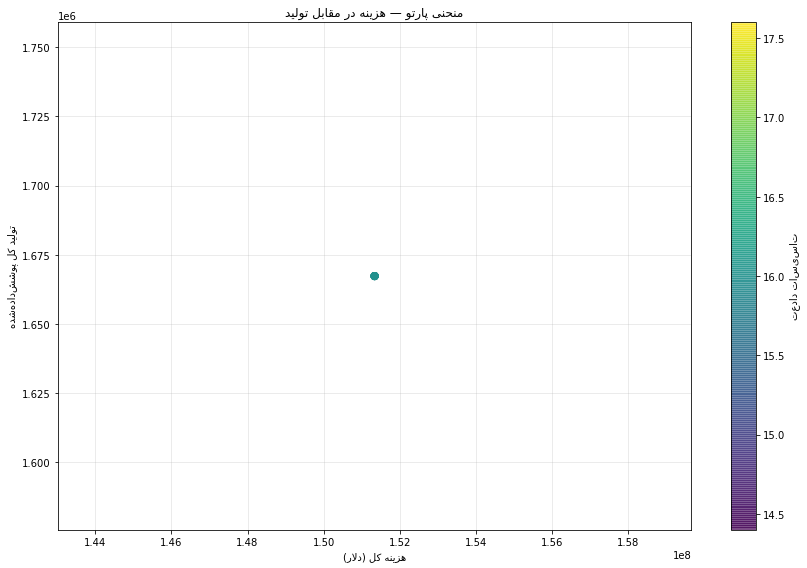

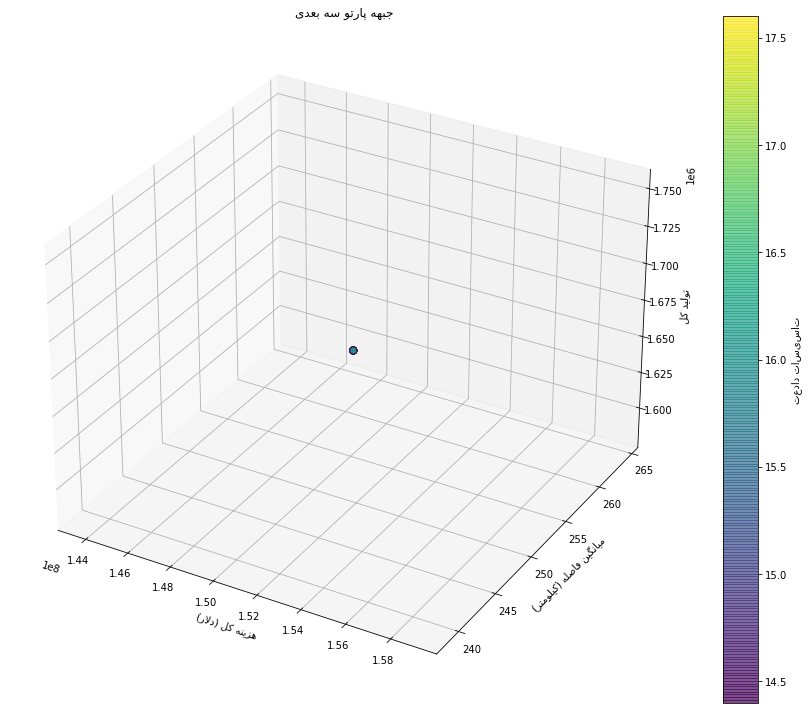

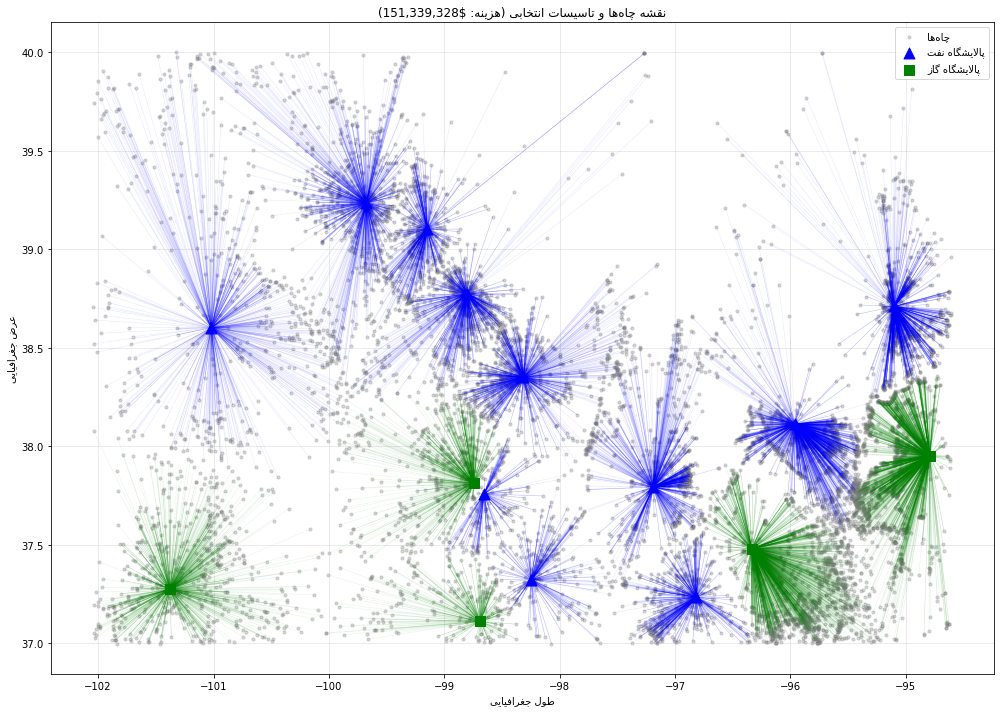

In [11]:
# ks_well_moo_analysis.py
# تحلیل مکانی و بهینه‌سازی چندهدفه (NSGA-II) برای دیتاست ks_well.txt

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
#from pymoo.core.constraint import Constraint
import arabic_reshaper
from bidi.algorithm import get_display

# ---------- تنظیمات اولیه ----------
INPUT_FILE = 'ks_wells.txt'
OUTPUT_DIR = 'ks_well_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# پارامترهای مدل اقتصادی واقع‌بینانه
CAPEX_OIL_FACILITY = 2500000  # هزینه احداث پالایشگاه نفت
CAPEX_GAS_FACILITY = 3000000  # هزینه احداث پالایشگاه گاز
CAPEX_COMBO_FACILITY = 4000000  # هزینه احداث پالایشگاه ترکیبی

PIPE_OIL_COST_PER_KM = 2000  # هزینه لوله‌کشی نفت به ازای هر کیلومتر
PIPE_GAS_COST_PER_KM = 2500  # هزینه لوله‌کشی گاز به ازای هر کیلومتر

EARTH_RADIUS_KM = 6371.0

# پارامترهای بهینه‌سازی
N_GEN = 25
POP_SIZE = 100
MAX_CANDIDATES = 30  # حداکثر تعداد کاندیداها

# پارامترهای نمونه‌برداری و محدودیت‌ها
SAMPLE_FRACTION = 0.05  # نسبت نمونه‌برداری از داده‌ها
MAX_BUDGET = 5000000000  # حداکثر بودجه (دلار)
MAX_FACILITIES = 1500  # حداکثر تعداد پالایشگاه‌ها
MAX_PIPE_LENGTH = 20000000  # حداکثر طول لوله‌کشی کل (کیلومتر)

# ---------- توابع کمکی ----------

def reshape_label(s):
    """بازگرداندن رشتهٔ فارسی با reshaping برای matplotlib"""
    try:
        return get_display(arabic_reshaper.reshape(s))
    except Exception:
        return s

def haversine_km(lat1, lon1, lat2, lon2):
    # all inputs in degrees, returns distance in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

# ---------- بارگذاری و پاکسازی داده ----------
print('بارگذاری داده...')
df = pd.read_csv(INPUT_FILE, quotechar='"')
for col in ['LATITUDE','LONGITUDE']:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(np.float32)

for col in ['IP_OIL','IP_GAS','IP_WATER']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0).astype(np.float32)
    else:
        df[col] = np.float32(0.0)

# فیلتر چاه‌های فعال
exclude_status = ['Plugged and Abandoned','Expired Intent to Drill (C-1)','SWD-P&A']
active_mask = ~df['STATUS'].isin(exclude_status)
active_df = df[active_mask].copy()
print(f'تعداد رکورد کل: {len(df)}, تعداد رکورد فعال پس از فیلتر: {len(active_df)}')

if len(active_df) == 0:
    active_df = df.copy()

active_df = active_df.dropna(subset=['LATITUDE','LONGITUDE']).reset_index(drop=True)

# نمونه‌برداری تصادفی برای کاهش حجم داده
if len(active_df) > 1000:
    sample_size = min(int(len(active_df) * SAMPLE_FRACTION), 10000)
    active_df = active_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
    print(f'نمونه‌گیری تصادفی: استفاده از {len(active_df)} رکورد از {int(len(active_df) / SAMPLE_FRACTION)} رکورد اصلی')

active_df.to_csv(os.path.join(OUTPUT_DIR,'ks_well_active.csv'), index=False)

# ---------- انتخاب کاندیداهای محدود بر اساس تراکم تولید ----------
print('انتخاب کاندیداهای محدود بر اساس تراکم تولید...')

# محاسبه تولید کل نفت و گاز در هر منطقه
active_df['TOTAL_OIL'] = active_df['IP_OIL']
active_df['TOTAL_GAS'] = active_df['IP_GAS']

# انتخاب مناطق با تولید بالا
high_oil_threshold = active_df['TOTAL_OIL'].quantile(0.8)
high_gas_threshold = active_df['TOTAL_GAS'].quantile(0.8)

high_oil_wells = active_df[active_df['TOTAL_OIL'] > high_oil_threshold]
high_gas_wells = active_df[active_df['TOTAL_GAS'] > high_gas_threshold]

# ترکیب و انتخاب کاندیداها
candidates_df = pd.concat([high_oil_wells, high_gas_wells]).drop_duplicates()
if len(candidates_df) > MAX_CANDIDATES:
    candidates_df = candidates_df.sample(n=MAX_CANDIDATES, random_state=42)

candidates_df = candidates_df[['LATITUDE', 'LONGITUDE', 'IP_OIL', 'IP_GAS']].copy()
candidates_df.columns = ['lat', 'lon', 'oil_prod', 'gas_prod']
candidates_df['n_wells'] = 1

print(f'تعداد کاندیداهای نهایی: {len(candidates_df)}')
candidates_df.to_csv(os.path.join(OUTPUT_DIR,'candidates.csv'), index=False)

# ---------- تعریف مسئلهٔ بهینه‌سازی پیشرفته با محدودیت‌ها ----------
K = len(candidates_df)
wells_coords = active_df[['LATITUDE','LONGITUDE']].values.astype(np.float32)
wells_oil = active_df['IP_OIL'].values.astype(np.float32)
wells_gas = active_df['IP_GAS'].values.astype(np.float32)
cand_coords = candidates_df[['lat','lon']].values.astype(np.float32)

# محاسبه ماتریس فاصله
print('محاسبه ماتریس فاصله...')
dist_matrix = np.zeros((len(wells_coords), K), dtype=np.float32)

for i in range(len(wells_coords)):
    for j in range(K):
        dist_matrix[i, j] = haversine_km(
            wells_coords[i, 0], wells_coords[i, 1],
            cand_coords[j, 0], cand_coords[j, 1]
        )
        
class MyProblem(Problem):
    def __init__(self):
        super().__init__(n_var=2,
                         n_obj=1,
                         n_ieq_constr=1,  # Number of inequality constraints
                         xl=-2.0,
                         xu=2.0)

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = x[:, 0]**2 + x[:, 1]**2
        g1 = x[:, 0] + x[:, 1] - 1  # Example constraint
        out["F"] = f1
        out["G"] = g1

class AdvancedFacilityLocationProblem(Problem):
    def __init__(self):
        # 3 نوع تصمیم برای هر کاندیدا: بدون تاسیس، تاسیس نفت، تاسیس گاز
        super().__init__(n_var=K*3, n_obj=3, n_constr=3, xl=0.0, xu=1.0)
        
    def _evaluate(self, x, out, *args, **kwargs):
        n_pop = x.shape[0]
        f1 = np.zeros(n_pop, dtype=np.float32)  # هزینه کل
        f2 = np.zeros(n_pop, dtype=np.float32)  # میانگین فاصله
        f3 = np.zeros(n_pop, dtype=np.float32)  # منفی تولید کل
        
        # محدودیت‌ها
        g1 = np.zeros(n_pop, dtype=np.float32)  # محدودیت بودجه
        g2 = np.zeros(n_pop, dtype=np.float32)  # محدودیت تعداد تاسیسات
        g3 = np.zeros(n_pop, dtype=np.float32)  # محدودیت طول لوله‌کشی
        
        for idx in range(n_pop):
            solution = x[idx].reshape(K, 3)  # بازسازی به شکل (کاندیداها × 3)
            
            # تعیین نوع تاسیس برای هر کاندیدا
            facility_types = np.argmax(solution, axis=1)  # 0: هیچکدام, 1: نفت, 2: گاز
            
            # محاسبه هزینه CAPEX
            capex = 0
            oil_facilities = np.sum(facility_types == 1)
            gas_facilities = np.sum(facility_types == 2)
            total_facilities = oil_facilities + gas_facilities
            
            capex += oil_facilities * CAPEX_OIL_FACILITY
            capex += gas_facilities * CAPEX_GAS_FACILITY
            
            # محاسبه هزینه لوله‌کشی
            pipe_cost = 0
            total_pipe_length = 0
            total_captured_oil = 0
            total_captured_gas = 0
            
            for i in range(len(wells_coords)):
                min_oil_dist = float('inf')
                min_gas_dist = float('inf')
                assigned_oil_facility = -1
                assigned_gas_facility = -1
                
                # یافتن نزدیک‌ترین تاسیس برای نفت و گاز
                for j in range(K):
                    if facility_types[j] in [1, 2]:  # تاسیس فعال
                        dist = dist_matrix[i, j]
                        if facility_types[j] == 1 and dist < min_oil_dist and wells_oil[i] > 0:
                            min_oil_dist = dist
                            assigned_oil_facility = j
                        if facility_types[j] == 2 and dist < min_gas_dist and wells_gas[i] > 0:
                            min_gas_dist = dist
                            assigned_gas_facility = j
                
                # محاسبه هزینه لوله‌کشی
                if assigned_oil_facility != -1:
                    pipe_cost += min_oil_dist * PIPE_OIL_COST_PER_KM
                    total_pipe_length += min_oil_dist
                    total_captured_oil += wells_oil[i]
                
                if assigned_gas_facility != -1:
                    pipe_cost += min_gas_dist * PIPE_GAS_COST_PER_KM
                    total_pipe_length += min_gas_dist
                    total_captured_gas += wells_gas[i]
            
            total_cost = capex + pipe_cost
            total_production = total_captured_oil + total_captured_gas
            
            # اهداف
            f1[idx] = total_cost  # هزینه کل
            f2[idx] = np.mean([d for d in dist_matrix.flatten() if d > 0]) if np.any(dist_matrix > 0) else 0  # میانگین فاصله
            f3[idx] = -total_production  # منفی تولید کل
            
            # محدودیت‌ها
            g1[idx] = (total_cost - MAX_BUDGET) / MAX_BUDGET  # محدودیت بودجه
            g2[idx] = (total_facilities - MAX_FACILITIES) / MAX_FACILITIES  # محدودیت تعداد تاسیسات
            g3[idx] = (total_pipe_length - MAX_PIPE_LENGTH) / MAX_PIPE_LENGTH  # محدودیت طول لوله‌کشی
        
        out['F'] = np.column_stack([f1, f2, f3]).astype(np.float32)
        out['G'] = np.column_stack([g1, g2, g3]).astype(np.float32)

# ---------- اجرا با NSGA-II ----------
print('اجرای NSGA-II...')
problem = AdvancedFacilityLocationProblem()
algorithm = NSGA2(
    pop_size=POP_SIZE,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.8, eta=10),
    mutation=PM(eta=15),
    eliminate_duplicates=True
)

res = minimize(problem,
               algorithm,
               ('n_gen', N_GEN),
               seed=42,
               verbose=True)

# نتایج
print('بهینه‌سازی تمام شد. استخراج نتایج...')
pareto_F = res.F.astype(np.float32)
pareto_X = res.X.astype(np.float32)
pareto_G = res.G.astype(np.float32) if hasattr(res, 'G') else None

# فیلتر راه‌حل‌های قابل قبول (رضایت‌بخش از محدودیت‌ها)
feasible_mask = np.all(pareto_G <= 0, axis=1) if pareto_G is not None else np.ones(len(pareto_F), dtype=bool)

if np.any(feasible_mask):
    feasible_F = pareto_F[feasible_mask]
    feasible_X = pareto_X[feasible_mask]
    print(f"تعداد راه‌حل‌های قابل قبول: {len(feasible_F)}")
else:
    print("هیچ راه‌حل قابل قبولی یافت نشد. نمایش همه راه‌حل‌ها...")
    feasible_F = pareto_F
    feasible_X = pareto_X

# تحلیل نتایج
solutions = []
for i in range(len(feasible_X)):
    solution = feasible_X[i].reshape(K, 3)
    facility_types = np.argmax(solution, axis=1)
    
    oil_count = np.sum(facility_types == 1)
    gas_count = np.sum(facility_types == 2)
    total_facilities = oil_count + gas_count
    
    solutions.append({
        'cost': feasible_F[i, 0],
        'avg_distance': feasible_F[i, 1],
        'total_production': -feasible_F[i, 2],
        'oil_facilities': oil_count,
        'gas_facilities': gas_count,
        'total_facilities': total_facilities,
        'feasible': feasible_mask[i] if i < len(feasible_mask) else True
    })

solutions_df = pd.DataFrame(solutions)
solutions_df.to_csv(os.path.join(OUTPUT_DIR,'pareto_solutions_analysis.csv'), index=False)

# ---------- نمایش نتایج ----------
plt.figure(figsize=(12, 8))

# رنگ‌بندی بر اساس امکان‌پذیری
if np.any(feasible_mask) and not np.all(feasible_mask):
    colors = ['red' if not feasible else 'green' for feasible in 
              (feasible_mask if len(feasible_mask) == len(solutions_df) else [True]*len(solutions_df))]
    plt.scatter(solutions_df['cost'], solutions_df['total_production'], 
                c=colors, s=50, alpha=0.7)
    plt.legend(handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='قابل قبول'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='غیرقابل قبول')
    ])
else:
    plt.scatter(solutions_df['cost'], solutions_df['total_production'], 
                c=solutions_df['total_facilities'], cmap='viridis', s=50, alpha=0.7)
    plt.colorbar(label='تعداد تاسیسات')

plt.xlabel(reshape_label('هزینه کل (دلار)'))
plt.ylabel(reshape_label('تولید کل پوشش‌داده‌شده'))
plt.title(reshape_label('منحنی پارتو — هزینه در مقابل تولید'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'pareto_cost_vs_prod.png'), dpi=200)

# نمایش نمودار سه بعدی
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    solutions_df['cost'], 
    solutions_df['avg_distance'], 
    solutions_df['total_production'],
    c=solutions_df['total_facilities'],
    cmap='viridis',
    s=50,
    alpha=0.7
)

ax.set_xlabel(reshape_label('هزینه کل (دلار)'))
ax.set_ylabel(reshape_label('میانگین فاصله (کیلومتر)'))
ax.set_zlabel(reshape_label('تولید کل'))
ax.set_title(reshape_label('جبهه پارتو سه بعدی'))
plt.colorbar(scatter, label='تعداد تاسیسات')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'pareto_3d.png'), dpi=200)

# انتخاب بهترین راه‌حل از نظر کارایی هزینه
if len(solutions_df) > 0:
    feasible_solutions = solutions_df[solutions_df['feasible']] if 'feasible' in solutions_df.columns else solutions_df
    if len(feasible_solutions) > 0:
        best_idx = np.argmax(feasible_solutions['total_production'] / feasible_solutions['cost'])
        best_solution = feasible_X[best_idx].reshape(K, 3) if len(feasible_solutions) == len(feasible_X) else feasible_X[0].reshape(K, 3)
        best_facility_types = np.argmax(best_solution, axis=1)
    else:
        best_idx = 0
        best_solution = feasible_X[best_idx].reshape(K, 3)
        best_facility_types = np.argmax(best_solution, axis=1)

    # ---------- رسم نقشه ----------
    plt.figure(figsize=(14, 10))
    # چاه‌ها
    plt.scatter(active_df['LONGITUDE'], active_df['LATITUDE'], s=10, alpha=0.3, 
                c='gray', label=reshape_label('چاه‌ها'))

    # تاسیسات انتخابی
    oil_facilities = candidates_df[best_facility_types == 1]
    gas_facilities = candidates_df[best_facility_types == 2]

    plt.scatter(oil_facilities['lon'], oil_facilities['lat'], s=120, 
                marker='^', c='blue', label=reshape_label('پالایشگاه نفت'))
    plt.scatter(gas_facilities['lon'], gas_facilities['lat'], s=120, 
                marker='s', c='green', label=reshape_label('پالایشگاه گاز'))

    # نمایش خطوط اتصال برای نزدیک‌ترین تاسیسات
    for i in range(len(wells_coords)):
        well_coord = wells_coords[i]
        min_dist = float('inf')
        nearest_facility = None
        facility_type = None
        
        for j in range(K):
            if best_facility_types[j] in [1, 2]:
                dist = haversine_km(well_coord[0], well_coord[1], 
                                   cand_coords[j, 0], cand_coords[j, 1])
                if dist < min_dist:
                    min_dist = dist
                    nearest_facility = j
                    facility_type = best_facility_types[j]
        
        if nearest_facility is not None:
            color = 'blue' if facility_type == 1 else 'green'
            alpha = 0.1 if min_dist > 50 else 0.3
            plt.plot([well_coord[1], cand_coords[nearest_facility, 1]], 
                     [well_coord[0], cand_coords[nearest_facility, 0]], 
                     color=color, alpha=alpha, linewidth=0.5)

    plt.xlabel(reshape_label('طول جغرافیایی'))
    plt.ylabel(reshape_label('عرض جغرافیایی'))
    plt.title(reshape_label(f'نقشه چاه‌ها و تاسیسات انتخابی (هزینه: ${solutions_df.iloc[best_idx]["cost"]:,.0f})'))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'map_facilities.png'), dpi=200)

# ---------- ذخیره نتایج مفصل ----------
detailed_results = []
for i, (idx, row) in enumerate(solutions_df.iterrows()):
    detailed_results.append({
        'solution_id': i,
        'total_cost': row['cost'],
        'total_production': row['total_production'],
        'avg_distance': row['avg_distance'],
        'oil_facilities': row['oil_facilities'],
        'gas_facilities': row['gas_facilities'],
        'total_facilities': row['total_facilities'],
        'cost_per_unit': row['cost'] / row['total_production'] if row['total_production'] > 0 else float('inf'),
        'feasible': row['feasible'] if 'feasible' in row else True
    })

detailed_df = pd.DataFrame(detailed_results)
detailed_df.to_csv(os.path.join(OUTPUT_DIR,'detailed_solutions.csv'), index=False)

print('\nنتایج بهینه‌سازی:')
print('=' * 50)
print(f"تعداد راه‌حل‌های پارتو: {len(solutions_df)}")
if len(solutions_df) > 0:
    best_solution = detailed_df.loc[detailed_df['cost_per_unit'].idxmin()]
    print(f"بهترین راه‌حل از نظر کارایی هزینه:")
    print(f"  - هزینه کل: ${best_solution['total_cost']:,.0f}")
    print(f"  - تولید کل: {best_solution['total_production']:,.0f} واحد")
    print(f"  - هزینه به ازای هر واحد: ${best_solution['cost_per_unit']:,.2f}")
    print(f"  - تعداد پالایشگاه نفت: {best_solution['oil_facilities']}")
    print(f"  - تعداد پالایشگاه گاز: {best_solution['gas_facilities']}")
    print(f"  - وضعیت: {'قابل قبول' if best_solution['feasible'] else 'غیرقابل قبول'}")

print(f"\nفایل‌های خروجی در پوشه: {OUTPUT_DIR}")
print('پایان.')